# ccRCC Fig4 — T cell replacement pre-train relabel 

In [1]:
import os, gc
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
from anndata.experimental import read_elem

sc.settings.verbosity = 1
sc.settings.seed = 0
np.random.seed(0)
sc.settings.set_figure_params(dpi=300, dpi_save=300, fontsize=7, facecolor="white")
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

variant = "unseen_scRNAseq_subtype"
combined_path = "/lustre/scratch126/cellgen/lotfollahi/zh4/Mintflow/Revisions/Adata_objects/adata_whole_combined.h5ad"
raw_section_dir = "/lustre/scratch126/cellgen/lotfollahi/zh4/Mintflow/Subclustering_analysis/adata_raw_per_section"
revisions_dir = "/lustre/scratch126/cellgen/lotfollahi/zh4/Mintflow/Revisions"
tcell_l4_key = "level_4_cell_type_with_Xmic_Tcell_and_XmicXint_merged_TAM_annotations"

dst_dir = f"{revisions_dir}/adata_raw_per_section_{variant}"
plot_dir = f"{revisions_dir}/Plots/{variant}"
os.makedirs(dst_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)
sc_meta_path = f"{revisions_dir}/Single_cell/Final_SCP_Metadata.txt"
sc_counts_path = f"{revisions_dir}/Single_cell/ccRCC_scRNASeq_NormalizedCounts.txt"
top_n_genes = 100

/nfs/team361/zh4/Environments/mintflow_perturbation_2/lib/python3.11/site-packages/anndata/experimental/__init__.py:48: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  return module_get_attr_redirect(


## 1. ICB gene program from external scRNA-seq (ICB-exposed vs treatment-naive T cells)

In [2]:
meta = pd.read_csv(sc_meta_path, sep="\t", skiprows=[1], index_col="NAME")
counts = pd.read_csv(sc_counts_path, sep="\t", index_col=0)      # genes x cells, log-normalized
counts = counts.astype(np.float32, copy=False).T                 # cells x genes
common = counts.index.intersection(meta.index)
adata_sc = ad.AnnData(X=counts.loc[common].to_numpy(),
                      obs=meta.loc[common].copy(),
                      var=pd.DataFrame(index=counts.columns.astype(str)))
del counts; gc.collect()

ct = adata_sc.obs["FinalCellType"].astype(str)
is_tcell = ct.str.contains("T cell") | ct.str.contains("T-Helper") | ct.eq("T-Reg")
adata_sc = adata_sc[is_tcell.to_numpy()].copy()
adata_sc.obs["ICB_Exposed"] = adata_sc.obs["ICB_Exposed"].astype("category")
print("scRNA T cells:", adata_sc.shape, adata_sc.obs["ICB_Exposed"].value_counts().to_dict())

scRNA T cells: (13090, 32718) {'ICB': 9278, 'NoICB': 3812}


In [3]:
sc.tl.rank_genes_groups(adata_sc, groupby="ICB_Exposed", groups=["ICB"],
                        reference="NoICB", method="wilcoxon", pts=True)
deg = sc.get.rank_genes_groups_df(adata_sc, group="ICB")
gp_full = deg.sort_values("scores", ascending=False)["names"].astype(str).head(top_n_genes).tolist()

with h5py.File(combined_path, "r") as f:
    panel = set(read_elem(f["var"]).index.astype(str))
gp = [g for g in gp_full if g in panel]
Path(f"{revisions_dir}/ICB_GP_{variant}.txt").write_text("\n".join(gp_full) + "\n")
print(f"GP: {len(gp_full)} DEGs, {len(gp)} present in the {len(panel)}-gene Xenium panel")
print(gp[:25])

GP: 100 DEGs, 21 present in the 5001-gene Xenium panel
['GZMK', 'CXCL13', 'LAG3', 'IFNG', 'CD27', 'GZMH', 'HSPA8', 'APOBEC3G', 'CXCR3', 'GZMA', 'GZMB', 'HAVCR2', 'IRF1', 'CD2', 'PRF1', 'SIRPG', 'EIF1AY', 'RBPJ', 'TAP1', 'SOD1', 'H3F3B']


## 2. Score treatment-naive (CV) T cells in the Xenium atlas

In [4]:
with h5py.File(combined_path, "r") as f:
    X = read_elem(f["X"])
    obs = read_elem(f["obs"])
    var = read_elem(f["var"])
adata = ad.AnnData(X=X, obs=obs, var=var)
del X, obs, var; gc.collect()

sn = adata.obs["section_name"].astype(str)
l4 = adata.obs[tcell_l4_key].astype(str)
mask = sn.str.startswith("CV").to_numpy() & l4.str.startswith("Tcell_").to_numpy()
adata_T = adata[mask].copy()
del adata; gc.collect()

sc.pp.log1p(adata_T)                                     # X is normalize_total output (not logged)
gp_in = [g for g in gp if g in adata_T.var_names]
sc.tl.score_genes(adata_T, gene_list=gp_in, score_name="ICB_score")
print("CV T cells:", adata_T.n_obs, "| genes used:", len(gp_in),
      "| ICB_score range:", float(adata_T.obs["ICB_score"].min()),
      float(adata_T.obs["ICB_score"].max()))

CV T cells: 282074 | genes used: 21 | ICB_score range: -0.6419780559530651 2.3293513843296205


## 3. Spatial maps — treatment-naive T cells coloured by ICB score

In [ ]:
score = adata_T.obs["ICB_score"].to_numpy()
vmin, vmax = np.nanpercentile(score, [5, 95])
sec = adata_T.obs["section_name"].astype(str).to_numpy()
xc = adata_T.obs["x_centroid"].to_numpy()
yc = adata_T.obs["y_centroid"].to_numpy()

for s in sorted(np.unique(sec)):
    m = sec == s
    fig, ax = plt.subplots(figsize=(3, 3))
    sp = ax.scatter(xc[m], yc[m], c=score[m], cmap="plasma", vmin=vmin, vmax=vmax,
                    s=2, linewidths=0)
    ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")
    ax.set_title(f"{s}  (n T = {int(m.sum())})", fontsize=7)
    cbar = fig.colorbar(sp, ax=ax, shrink=0.6)
    cbar.ax.tick_params(labelsize=6); cbar.set_label("ICB score", fontsize=7)
    fig.savefig(f"{plot_dir}/{s}_ICB_score.svg", bbox_inches="tight")
    plt.show(); plt.close(fig)

## 4. Relabel top 5% scoring T cells per subtype (CD4+/CD8+/DN T lymphocyte ICB)

In [ ]:
top_pct = 5
relabel_map = {
    "CD4+ T lymphocyte": "CD4+ T lymphocyte ICB",
    "CD8+ T lymphocyte": "CD8+ T lymphocyte ICB",
    "DN T lymphocyte": "DN T lymphocyte ICB",
}

adata_T.obs["file"] = adata_T.obs["batch"].astype(str).map(os.path.basename)
l3 = adata_T.obs["level_3_cell_type"].astype(str).to_numpy()
score = adata_T.obs["ICB_score"].to_numpy()
files = adata_T.obs["file"].to_numpy()
cell_ids = adata_T.obs["cell_id"].astype(str).to_numpy()

# top 5% WITHIN each T-cell subtype individually -> its own subtype-specific ICB label
sel = {}  # {file: {cell_id: new_label}}
for subtype, new_label in relabel_map.items():
    m = l3 == subtype
    n = int(m.sum())
    if n == 0:
        print(f"{subtype}: 0 cells")
        continue
    thr = np.percentile(score[m], 100 - top_pct)
    picked = m & (score >= thr)
    for f, cid in zip(files[picked], cell_ids[picked]):
        sel.setdefault(f, {})[cid] = new_label
    print(f"{subtype}: {n} cells, thr(p{100 - top_pct})={thr:.4f}, "
          f"top {top_pct}% = {int(picked.sum())} -> '{new_label}'")

new_labels = list(relabel_map.values())
cv_files = sorted(f for f in os.listdir(raw_section_dir)
                  if f.startswith("CV") and f.endswith(".h5ad"))
for i, fn in enumerate(cv_files):
    a = sc.read_h5ad(os.path.join(raw_section_dir, fn))
    file_map = sel.get(fn, {})
    if file_map:
        add = [v for v in new_labels if v not in a.obs["level_3_cell_type"].cat.categories]
        if add:
            a.obs["level_3_cell_type"] = a.obs["level_3_cell_type"].cat.add_categories(add)
        mapped = a.obs["cell_id"].astype(str).map(file_map)
        mask = mapped.notna()
        a.obs.loc[mask, "level_3_cell_type"] = mapped[mask].to_numpy()
        a.obs["level_3_cell_type"] = a.obs["level_3_cell_type"].cat.remove_unused_categories()
        print(f"[{i + 1}/{len(cv_files)}] {fn}: relabelled {int(mask.sum())} cells")
    else:
        print(f"[{i + 1}/{len(cv_files)}] {fn}: no top-{top_pct}% cells")
    a.write_h5ad(os.path.join(dst_dir, fn))
    del a; gc.collect()
print("dst_dir ready:", dst_dir, "| CV files:", len(cv_files))

# ccRCC Fig4 — T cell replacement analysis

# Setup

In [1]:
### Import libraries
import gc
import os

import anndata as ad
import h5py
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import torch
from anndata.io import read_elem
from geomloss import SamplesLoss
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from sklearn.decomposition import PCA

### Set random seed
sc.settings.seed = 0
np.random.seed(0)
torch.manual_seed(0)

### Set plotting parameters
plt.rcParams.update({'font.size': 7, 'pdf.fonttype': 42, 'ps.fonttype': 42})
line_lw = 0.25
line_color = 'black'

### Check GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)


cuda:0


In [2]:
### Paths
dir_save = \
'/lustre/scratch126/cellgen/lotfollahi/zh4/Mintflow/Final/Perturbations/Akbar_notebook_final/orig_batch09_50seed'
dir_plots = '/lustre/scratch126/cellgen/lotfollahi/zh4/Mintflow/Final/Plots_revision'
root_generations = f'{dir_save}/generations_50seed'
root_crops = '/lustre/scratch126/cellgen/lotfollahi/zh4/Mintflow/Subclustering_analysis/adata_TLS_cropped_combined'
root_sections = ('/lustre/scratch126/cellgen/lotfollahi/zh4/Mintflow/Subclustering_analysis/'
                 'adata_raw_per_section')
macrophage_reference_path = '/nfs/team361/cl35/Macs/adata_macrophages.h5ad'

os.makedirs(dir_save, exist_ok=True)
os.makedirs(dir_plots, exist_ok=True)

# the plot directory is shared with the sibling Akbar notebooks, so every svg carries this prefix
nb_tag = 'orig_batch09_50seed'


def plot_path(name):
    return f'{dir_plots}/{nb_tag}_{name}.svg'


### Experiment layout
sections = [
    'CV1-KID-0-FO-1',
    'CV1-KID-0-FT-2',
    'CV5-KID-0-FO-1',
    'CV6-KID-0-FT-1',
    'CV7-KID-0-FT-2-s3',
    'CV9-KID-0-FT-2',
]
gt_treated_sections = ['DI13-KID-0-FT-1', 'DI10-KID-0-FT-3']
seeds_outerloop = list(range(50))

ct_filter = 'Tumour associated macrophage'
mcc_reference_mode = 'full_replacement'
key_xmic = 'MintFLow_Generated_Xmic'
key_full = 'MintFlow_Generated_Xint_plus_Xmic'
pseudo = 1e-9

modes = [
    'full_replacement',
    'dose_response_25pct',
    'dose_response_50pct',
    'dose_response_75pct',
    'random_cells_uniform',
]
modes_to_generate = ['unperturbed'] + modes
sink_arms = ['full_replacement', 'random_cells_uniform']
plot_modes = ['full_replacement', 'random_cells_uniform']
box_modes = ['unperturbed', 'full_replacement', 'random_cells_uniform']

mode_label = {
    'unperturbed': 'Unperturbed',
    'full_replacement': 'Full replacement',
    'dose_response_25pct': 'Dose 25%',
    'dose_response_50pct': 'Dose 50%',
    'dose_response_75pct': 'Dose 75%',
    'random_cells_uniform': 'Random relabel',
}
arm_color = {
    'unperturbed': '#B0B0B0',
    'full_replacement': '#fab673',
    'random_cells_uniform': '#4f278b',
}


def gen_path(section, mode):
    sub = 'shared_unperturbed' if mode == 'unperturbed' else mode
    tag = 'unperturbed' if mode == 'unperturbed' else 'perturbed'
    return f'{root_generations}/{sub}/generated_adatas/{section}__{tag}.h5ad'


def seed_gen_path(section, mode, seed):
    """Per-seed generation, written by the Akbar_generate_orig_batch09_50seed.py array job."""
    sub = 'shared_unperturbed' if mode == 'unperturbed' else mode
    tag = 'unperturbed' if mode == 'unperturbed' else 'perturbed'
    return f'{root_generations}/{sub}/seed_adatas_seed{seed:02d}/{section}__{tag}.h5ad'


def base_label_path(section):
    return f'{root_crops}/{section}_crop.h5ad'


In [3]:
### Shared helpers
def tam_mask(a):
    lab = a.obs['level_4_cell_type'].astype(str).replace({'nan': 'NA', 'None': 'NA'}).to_numpy()
    return lab != 'NA'


def cp10k(x):
    x = np.clip((x.toarray() if sp.issparse(x) else np.asarray(x)).astype(np.float32), 0, None)
    total = x.sum(1, keepdims=True)
    total[total == 0] = 1.0
    return np.log1p(x * (1e4 / total))


def mcc_changed(section):
    """Unperturbed arm, reference arm, and the cell ids whose mcc vector differs between them."""
    ctrl = sc.read_h5ad(gen_path(section, 'unperturbed'))
    cid_ctrl = pd.Index(ctrl.obs['cell_id'].astype(str))
    ref = sc.read_h5ad(gen_path(section, mcc_reference_mode))
    cid_ref = pd.Index(ref.obs['cell_id'].astype(str))
    shared = cid_ctrl.intersection(cid_ref)
    changed = ~np.isclose(
        ctrl.obsm['MintFLow_np_MCC'][cid_ctrl.get_indexer(shared)],
        ref.obsm['MintFLow_np_MCC'][cid_ref.get_indexer(shared)],
    ).all(1)
    return ctrl, ref, set(shared[changed])


def gp_columns(gene_sets):
    """Panel column indices per gene set, plus the union used to slice the per-cell matrices."""
    cols = {k: panel.get_indexer([g for g in v if g in panel]) for k, v in gene_sets.items()}
    non_empty = [c for c in cols.values() if len(c)]
    union = np.unique(np.concatenate(non_empty)) if non_empty else np.zeros(0, dtype=int)
    return union, {k: np.searchsorted(union, c) for k, c in cols.items() if len(c)}


def style_axes(ax):
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_linewidth(line_lw)
        ax.spines[spine].set_color(line_color)
    ax.tick_params(axis='both', colors=line_color, width=line_lw)
    ax.grid(False)


def print_gene_list(genes, per_line=8):
    for i in range(0, len(genes), per_line):
        print(', '.join(genes[i:i + per_line]))


def print_gene_set(name, pairs, per_line=4):
    items = [f'"{g}": {v:.4f}' for g, v in pairs]
    print(f'{name} = {{')
    for i in range(0, len(items), per_line):
        print('    ' + ', '.join(items[i:i + per_line]) + (',' if i + per_line < len(items) else ''))
    print('}')


In [4]:
### Tam level4 subtype reference, used by add_level4() below
with h5py.File(macrophage_reference_path, 'r') as f:
    ref_level4 = pd.Series(
        np.asarray(read_elem(f['obs']['Annotation_TAMs_merged'])).astype(str),
        index=pd.MultiIndex.from_arrays(
            [np.asarray(read_elem(f['obs']['batch'])).astype(str),
             np.asarray(read_elem(f['obs']['_index'])).astype(str)],
            names=['batch', 'cell_id'],
        ),
    )
ref_level4 = ref_level4[~ref_level4.index.duplicated(keep='first')]


def add_level4(adata):
    key = pd.MultiIndex.from_arrays(
        [adata.obs['batch'].astype(str).to_numpy(), adata.obs_names.astype(str)],
        names=['batch', 'cell_id'],
    )
    adata.obs['level_4_cell_type'] = pd.Categorical(ref_level4.reindex(key).to_numpy())
    return adata


In [5]:
### Aggregate the per-seed generations produced by the array job
todo = [(section, mode) for mode in modes_to_generate for section in sections
        if not os.path.exists(gen_path(section, mode))]
print(f'{len(todo)} aggregated generations missing')

for section, mode in todo:
    missing_seeds = [seed for seed in seeds_outerloop
                     if not os.path.exists(seed_gen_path(section, mode, seed))]
    if missing_seeds:
        raise FileNotFoundError(
            f'{section} {mode}: missing per-seed generations for seeds {missing_seeds}; '
            'run the Akbar_generate_orig_batch09_50seed.sh array job first'
        )

    xmic, xint, adata = [], [], None
    for seed in seeds_outerloop:
        seed_adata = sc.read_h5ad(seed_gen_path(section, mode, seed))
        xmic.append(seed_adata.obsm[key_xmic])
        xint.append(seed_adata.obsm['MintFlow_Generated_Xint'])
        np_mcc = seed_adata.obsm['MintFLow_np_MCC']
        if seed == seeds_outerloop[-1]:
            adata = seed_adata
        else:
            del seed_adata
        gc.collect()

    adata.obsm[key_xmic] = np.stack(xmic, 0).mean(0)
    adata.obsm['MintFlow_Generated_Xint'] = np.stack(xint, 0).mean(0)
    adata.obsm[key_full] = adata.obsm['MintFlow_Generated_Xint'] + adata.obsm[key_xmic]
    adata.obsm['MintFLow_np_MCC'] = np_mcc
    os.makedirs(os.path.dirname(gen_path(section, mode)), exist_ok=True)
    adata.write_h5ad(gen_path(section, mode))
    print(section, mode, adata.n_obs, len(xmic), flush=True)

    del adata, xmic, xint
    gc.collect()


0 aggregated generations missing


In [6]:
### Gene panel shared by every generated arm
with h5py.File(gen_path(sections[0], 'unperturbed'), 'r') as f:
    panel = read_elem(f['var']).index.astype(str)
panel_genes = set(panel)
print(f'{len(panel)} panel genes')


5001 panel genes


# Sinkhorn

In [7]:
### Sinkhorn parameters
n_hvgs = [250, 500]
n_hvg_obs = 5001
n_pcs_obs = 50
min_sink_cells = 20
obs_min_pct = 0.25

loss_fn = SamplesLoss(loss='sinkhorn', p=2, blur=0.05, scaling=0.9, debias=True,
                      backend='tensorized')


def sinkhorn(x_a, x_b):
    with torch.no_grad():
        a = torch.as_tensor(np.ascontiguousarray(x_a, dtype=np.float32), device=device)
        b = torch.as_tensor(np.ascontiguousarray(x_b, dtype=np.float32), device=device)
        return float(loss_fn(a, b).item())


In [8]:
### Load observed untreated + treated tam cells, filter by pct first, then batch-aware hvgs
obs_adatas = {}
for s in sections + gt_treated_sections:
    a = sc.read_h5ad(base_label_path(s))
    a = a[(a.obs['level_3_cell_type'] == ct_filter).to_numpy()].copy()
    a.obs['section'] = s
    obs_adatas[s] = a
    print(s, 'treated' if s in gt_treated_sections else 'untreated', a.n_obs)

pooled_counts = ad.concat(list(obs_adatas.values()), join='inner')
sec_labels = pooled_counts.obs['section'].astype(str).to_numpy()
detected = np.logical_and.reduce(
    [np.asarray((pooled_counts.X[sec_labels == s] > 0).sum(0)).ravel() > 0 for s in obs_adatas]
)
pooled_counts = pooled_counts[:, detected].copy()

pct_obs = pd.Series(np.asarray((pooled_counts.X > 0).mean(0)).ravel(),
                    index=pooled_counts.var_names.astype(str))
n_before = pooled_counts.n_vars
pooled_counts = pooled_counts[:, (pct_obs >= obs_min_pct).to_numpy()].copy()

sc.pp.highly_variable_genes(pooled_counts, flavor='seurat_v3',
                            n_top_genes=min(n_hvg_obs, pooled_counts.n_vars),
                            batch_key='section')

hvg_ranked_obs = (pooled_counts.var['highly_variable_rank'].dropna().sort_values()
                  .index.astype(str).tolist())
sink_genes_obs = [g for g in hvg_ranked_obs if g in panel_genes]

print(f'{n_before} genes detected, {pooled_counts.n_vars} pass pct >= {obs_min_pct:.0%}, '
      f'hvg fit on {pooled_counts.n_obs} tam cells from {len(obs_adatas)} sections gives '
      f'{len(hvg_ranked_obs)} hvgs, {len(sink_genes_obs)} in the generated panel')

x_obs = {}
for s, a in obs_adatas.items():
    a = a.copy()
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)
    x = a.X[:, [a.var_names.get_loc(g) for g in sink_genes_obs]]
    x_obs[s] = np.asarray(x.toarray() if sp.issparse(x) else x, dtype=np.float32)

del obs_adatas, pooled_counts, sec_labels, detected
gc.collect()


CV1-KID-0-FO-1 untreated 3461
CV1-KID-0-FT-2 untreated 3143
CV5-KID-0-FO-1 untreated 492
CV6-KID-0-FT-1 untreated 2188
CV7-KID-0-FT-2-s3 untreated 546
CV9-KID-0-FT-2 untreated 1956
DI13-KID-0-FT-1 treated 618
DI10-KID-0-FT-3 treated 1403


/nfs/team361/zh4/Environments/mintflow_perturbation_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/zh4/Environments/mintflow_perturbation_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/zh4/Environments/mintflow_perturbation_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


3483 genes detected, 701 pass pct >= 25%, hvg fit on 13807 tam cells from 8 sections gives 701 hvgs, 701 in the generated panel


7888

In [9]:
### Print the sinkhorn hvg gene list
print(f'{len(sink_genes_obs)} sinkhorn hvgs, ranked:')
print_gene_list(sink_genes_obs)


701 sinkhorn hvgs, ranked:
ENPP2, COL4A1, THBS1, NR4A1, HMOX1, SLC40A1, CYP27A1, ADAMTS1
FUCA1, COL18A1, ACP5, NDRG1, C4A, C4B, OLFML3, ANPEP
PLAUR, LGMN, WDFY4, ITGA3, UBD, CA9, ANGPTL4, EPAS1
GBP1, CTSL, CXCL12, TUBB, CA12, PLTP, VSIG4, IRF1
TREM2, GBP5, ICAM1, VCAM1, TNFRSF21, ENPEP, STAB1, LIPA
CD14, CDK18, CDH6, C5AR1, APP, PFKP, ANXA2, GLA
NR1H3, PLIN2, MYC, TGM2, CDKN1A, VEGFA, EPHX1, CTSC
MRC1, LTA4H, SIGLEC1, SEMA4C, XBP1, PFKFB3, MX1, CD44
IRF8, OAS3, CREG1, ST14, ITGAX, MCM5, HYOU1, FPR1
NCF1, WARS, CMKLR1, EGLN3, CCR1, ITGAL, NCEH1, SELPLG
PTGER4, ERRFI1, NFKB2, SLC29A1, CD68, MXRA7, TMEM173, HSPA6
PGD, CEBPA, CD82, SDC3, MRC2, ADGRE2, NPC1, ADGRE5
TAP1, APOL1, LDHA, NRP1, FCGR3A, INSR, POR, ENG
IDH1, KDM6B, MYOF, CYBB, FCGR1A, LAMP1, MYO1E, SGK1
JAK3, ACLY, P2RX7, PEA15, SPTBN1, CD38, KPNA2, ITGA4
DMXL2, SERPINB9, LILRB1, ACTN1, GAS6, NAAA, PKM, PALLD
MDM2, BCL2L1, PTGS1, ZFYVE26, MSR1, SEMA4D, NINJ1, C3AR1
GIMAP5, FERMT3, RHOC, DNMT1, PLEKHA1, CSF2RA, CD72, SORL1
TES, PGK

In [10]:
### Fit pca on untreated + treated together, unscaled
fits_joint_unscaled = {}
for n_top in n_hvgs:
    n_keep = min(n_top, len(sink_genes_obs))
    pool = np.vstack([x_obs[s][:, :n_keep] for s in x_obs])
    pca = PCA(n_components=min(n_pcs_obs, n_keep - 1), random_state=0).fit(np.clip(pool, -10, 10))
    gt_pca = {s: pca.transform(np.clip(x_obs[s][:, :n_keep], -10, 10)) for s in gt_treated_sections}
    fits_joint_unscaled[n_top] = (n_keep, pca, gt_pca)
    print(f'top {n_top}: {n_keep} genes, {pca.n_components_} pcs, '
          f'fit on {pool.shape[0]} cells from {len(x_obs)} sections')
    del pool
    gc.collect()


top 250: 250 genes, 50 pcs, fit on 13807 cells from 8 sections
top 500: 500 genes, 50 pcs, fit on 13807 cells from 8 sections


In [11]:
### Calculate sinkhorn divergence
sink_rows = []
for section in sections:
    ctrl, ref, changed_ids = mcc_changed(section)
    del ref
    gc.collect()

    cols = [ctrl.var_names.get_loc(g) for g in sink_genes_obs]
    for mode in box_modes:
        arm = ctrl if mode == 'unperturbed' else sc.read_h5ad(gen_path(section, mode))
        keep = pd.Index(arm.obs['cell_id'].astype(str)).isin(changed_ids) & tam_mask(arm)
        print(section, mode, int(keep.sum()), flush=True)

        if keep.sum() >= min_sink_cells:
            x_all = cp10k(arm.obsm[key_full][keep])[:, cols]
            for n_top, (n_keep, pca, gt_pca) in fits_joint_unscaled.items():
                x = pca.transform(np.clip(x_all[:, :n_keep], -10, 10))
                for name, y in gt_pca.items():
                    sink_rows.append({'section': section, 'arm': mode, 'gt_section': name,
                                      'n_hvg': n_top, 'n_cells': int(keep.sum()),
                                      'n_gt_cells': int(y.shape[0]), 'sinkhorn': sinkhorn(x, y)})
            if device.type == 'cuda':
                torch.cuda.empty_cache()
            del x_all

        if mode != 'unperturbed':
            del arm
        gc.collect()

    del ctrl
    gc.collect()

sink_df = pd.DataFrame(sink_rows)


CV1-KID-0-FO-1 unperturbed 2760
CV1-KID-0-FO-1 full_replacement 2760
CV1-KID-0-FO-1 random_cells_uniform 2760
CV1-KID-0-FT-2 unperturbed 2789
CV1-KID-0-FT-2 full_replacement 2789
CV1-KID-0-FT-2 random_cells_uniform 2789
CV5-KID-0-FO-1 unperturbed 442
CV5-KID-0-FO-1 full_replacement 442
CV5-KID-0-FO-1 random_cells_uniform 442
CV6-KID-0-FT-1 unperturbed 1887
CV6-KID-0-FT-1 full_replacement 1887
CV6-KID-0-FT-1 random_cells_uniform 1887
CV7-KID-0-FT-2-s3 unperturbed 527
CV7-KID-0-FT-2-s3 full_replacement 527
CV7-KID-0-FT-2-s3 random_cells_uniform 527
CV9-KID-0-FT-2 unperturbed 1910
CV9-KID-0-FT-2 full_replacement 1910
CV9-KID-0-FT-2 random_cells_uniform 1910


Full replacement: mean delta=4.3943, sem=0.6808
Random relabel: mean delta=-2.3762, sem=0.2264


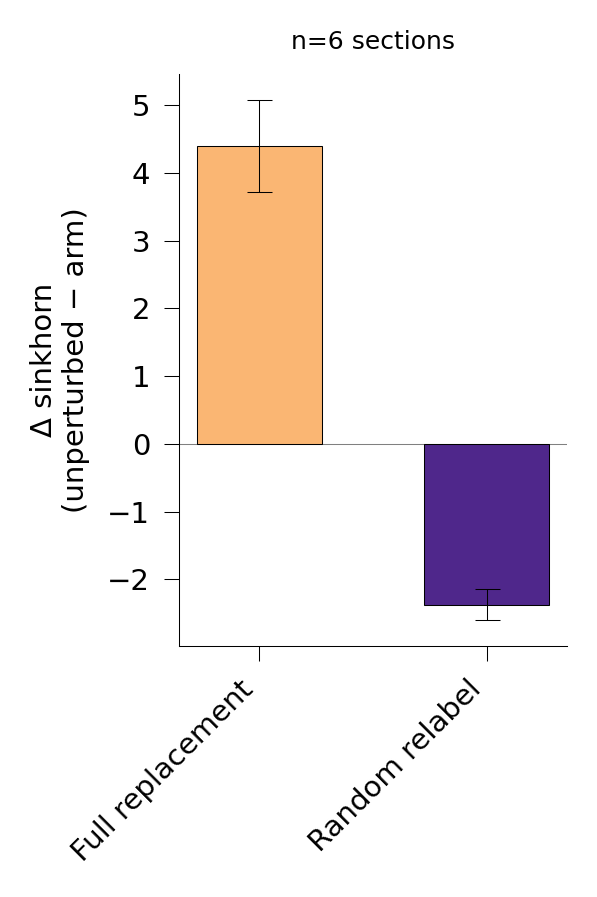

In [12]:
### Delta sinkhorn, unperturbed - arm, aggregated per section
sink_wide = sink_df.pivot_table(index=['section', 'gt_section'], columns='arm', values='sinkhorn')
delta = pd.DataFrame({arm: sink_wide['unperturbed'] - sink_wide[arm]
                      for arm in sink_arms}).reset_index()
delta.to_csv(f'{dir_save}/sinkhorn_delta_joint_unscaled.csv', index=False)

delta_by_section = delta.groupby('section')[sink_arms].mean()
n_sections = len(delta_by_section)
positions = np.arange(len(sink_arms))
means = [delta_by_section[arm].mean() for arm in sink_arms]
sems = [delta_by_section[arm].std(ddof=1) / np.sqrt(n_sections) for arm in sink_arms]
for arm, m, s in zip(sink_arms, means, sems):
    print(f'{mode_label[arm]}: mean delta={m:.4f}, sem={s:.4f}')

fig, ax = plt.subplots(figsize=(2.0, 3.0), dpi=300)
ax.bar(positions, means, 0.55, yerr=sems, capsize=3,
       color=[arm_color[arm] for arm in sink_arms], edgecolor=line_color, linewidth=line_lw,
       error_kw=dict(elinewidth=line_lw, capthick=line_lw))
ax.axhline(0, color='grey', linewidth=line_lw, zorder=0)
ax.set_xticks(positions)
ax.set_xticklabels([mode_label[arm] for arm in sink_arms], rotation=45, ha='right')
ax.set_ylabel('Δ sinkhorn\n(unperturbed − arm)')
ax.set_title(f'n={n_sections} sections', fontsize=6)
style_axes(ax)
fig.tight_layout()
fig.savefig(plot_path('sinkhorn_delta_combined_joint_unscaled'), format='svg', dpi=600,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)


Full replacement: mean sinkhorn=319.8092, sem=1.8667
Unperturbed: mean sinkhorn=324.2034, sem=1.2171
Random relabel: mean sinkhorn=326.5796, sem=1.1031


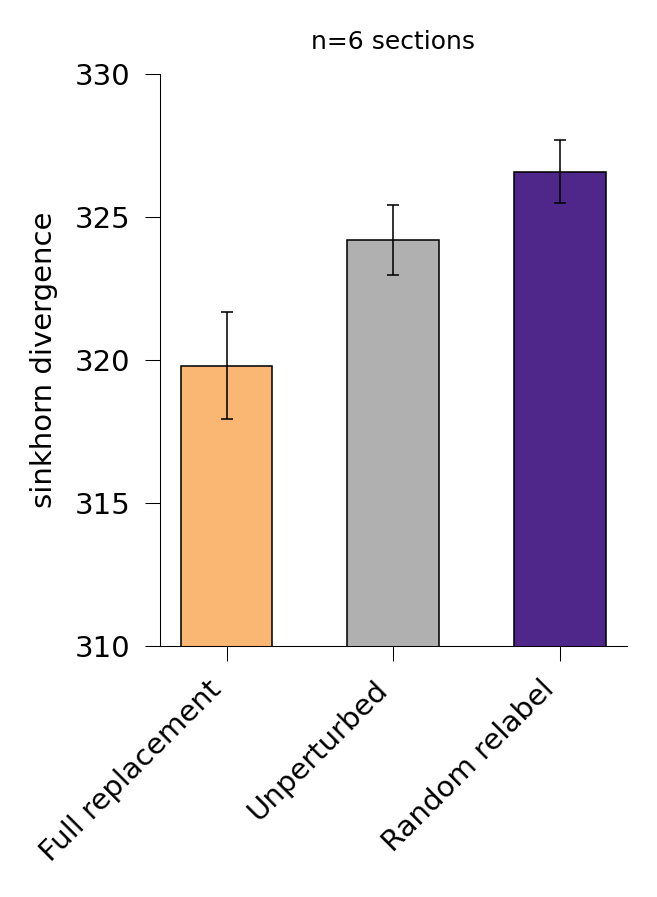

In [13]:
### Absolute sinkhorn, three arms, aggregated per section
arm_order = ['full_replacement', 'unperturbed', 'random_cells_uniform']
abs_by_section = sink_wide.groupby('section')[arm_order].mean()
n_sections = len(abs_by_section)
positions = np.arange(len(arm_order))
means = [abs_by_section[arm].mean() for arm in arm_order]
sems = [abs_by_section[arm].std(ddof=1) / np.sqrt(n_sections) for arm in arm_order]
for arm, m, s in zip(arm_order, means, sems):
    print(f'{mode_label[arm]}: mean sinkhorn={m:.4f}, sem={s:.4f}')

fig, ax = plt.subplots(figsize=(2.2, 3.0), dpi=300)
ax.bar(positions, means, 0.55, yerr=sems, capsize=1.5,
       color=[arm_color[arm] for arm in arm_order], edgecolor=line_color, linewidth=line_lw * 1.5,
       error_kw=dict(elinewidth=line_lw * 1.5, capthick=line_lw * 1.5))
ax.set_xticks(positions)
ax.set_xticklabels([mode_label[arm] for arm in arm_order], rotation=45, ha='right')
ax.set_ylabel('sinkhorn divergence')
ax.set_ylim(310, 330)
ax.set_yticks(np.arange(310, 331, 5))
ax.set_title(f'n={n_sections} sections', fontsize=6)
style_axes(ax)
fig.tight_layout()
fig.savefig(plot_path('sinkhorn_absolute_combined_joint_unscaled_3arm'), format='svg', dpi=600,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)


# Spatial plots

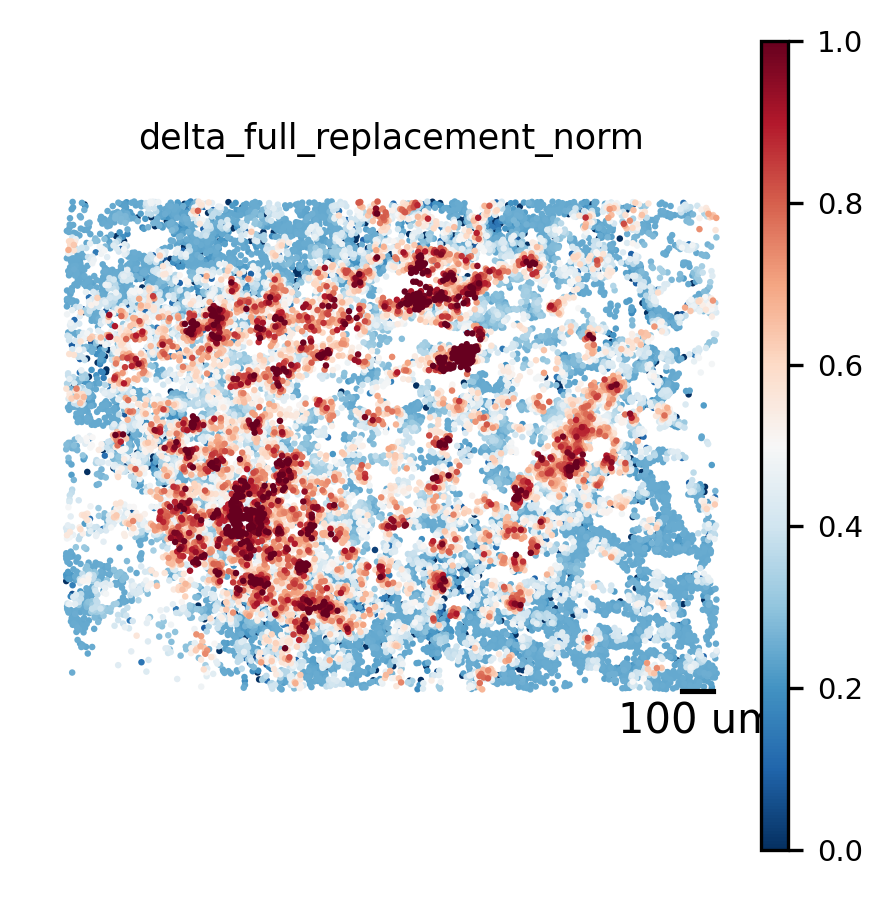

In [14]:
### Xmic gene-program score delta on tissue, full replacement minus unperturbed
def shared_control_genes(expr, var_names, gene_list, ctrl_size=50, n_bins=25, seed=0):
    """scanpy's control-set selection, frozen once so every arm subtracts the same background"""
    obs_avg = pd.Series(expr.mean(0), index=var_names)
    n_items = int(np.round(len(obs_avg) / (n_bins - 1)))
    obs_cut = obs_avg.rank(method='min') // n_items
    rng = np.random.default_rng(seed)
    control = []
    for cut in np.unique(obs_cut.loc[gene_list]):
        pool = obs_cut.index[obs_cut == cut].to_numpy()
        control.extend(rng.choice(pool, min(ctrl_size, pool.size), replace=False))
    return [g for g in pd.unique(control) if g not in set(gene_list)]


def gp_score(adata, genes, control, obsm_key=key_xmic):
    expr = np.log1p(np.clip(np.asarray(adata.obsm[obsm_key], dtype=np.float64), 0, None))
    return (expr[:, adata.var_names.get_indexer(genes)].mean(1)
            - expr[:, adata.var_names.get_indexer(control)].mean(1))


gp_genes = [
    'VCAM1', 'C4A', 'SOST', 'UBD', 'PTPRF', 'C4B', 'CDK18', 'BNIP3',
    'SHMT2', 'ENPP3', 'ALDOA', 'P4HA1', 'DUSP23', 'ARF1', 'GGT1', 'ABI3',
    'LGALS9', 'MYC', 'FNDC3B', 'RNF187',
]
spatial_section = 'CV1-KID-0-FT-2'

adata_spatial = sc.read_h5ad(gen_path(spatial_section, 'unperturbed'))
expr_ref = np.log1p(np.clip(np.asarray(adata_spatial.obsm[key_xmic], dtype=np.float64), 0, None))
control_genes = shared_control_genes(expr_ref, adata_spatial.var_names, gp_genes)
score_unp = gp_score(adata_spatial, gp_genes, control_genes)
del expr_ref
gc.collect()

a = sc.read_h5ad(gen_path(spatial_section, 'full_replacement'))
assert (a.obs['cell_id'].astype(str).to_numpy()
        == adata_spatial.obs['cell_id'].astype(str).to_numpy()).all()
adata_spatial.obs['delta_full_replacement'] = gp_score(a, gp_genes, control_genes) - score_unp
del a
gc.collect()

vals = adata_spatial.obs['delta_full_replacement'].to_numpy()
val_min, val_max = np.nanpercentile(vals, [2.5, 97.5])
adata_spatial.obs['delta_full_replacement_norm'] = np.clip(
    (vals - val_min) / (val_max - val_min), 0, 1)

fig, ax = plt.subplots(figsize=(3, 3), dpi=300)
sc.pl.spatial(
    adata_spatial,
    color='delta_full_replacement_norm',
    cmap='RdBu_r',
    vmin=0,
    vmax=1,
    na_color='lightgray',
    size=2,
    spot_size=10,
    frameon=False,
    show=False,
    ax=ax,
)
ax.add_artist(AnchoredSizeBar(
    ax.transData,
    100,
    '100 um',
    'lower right',
    pad=-0.7,
    color='black',
    frameon=False,
    size_vertical=2,
    fontproperties=fm.FontProperties(size=10),
))
fig.tight_layout()
fig.savefig(plot_path(f'spatial_gp_delta_full_replacement_{spatial_section}'), format='svg',
            dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)


# GP analysis

In [15]:
### Tam pseudobulk deseq2 across all sections, sequencing depth as a covariate
deg_p_max = 0.05
deg_min_abs_lfc = 0.5
min_tam_cells = 100
min_pct_tam = 0.25
deg_tag = 'deseq2_depthcov'
icb_drugs = ('Ipi/Novo', 'Ipi/Novo/Sutinib')

pb_counts, pb_meta, genes = {}, [], None
tam_det = None
n_tam_cells = 0
for fn in sorted(f for f in os.listdir(root_sections) if f.endswith('.h5ad')):
    s = fn[:-len('.h5ad')]
    a = sc.read_h5ad(f'{root_sections}/{fn}')
    treated = bool(a.obs['drug'].astype(str).isin(icb_drugs).any())
    m = (a.obs['level_3_cell_type'] == ct_filter).to_numpy()
    if genes is None:
        genes = a.var_names.astype(str)
        tam_det = np.zeros(len(genes))
    elif not genes.equals(a.var_names.astype(str)):
        raise ValueError(f'{s} carries a different panel')

    x_tam = a.layers['counts'][m]
    pb_counts[s] = np.asarray(x_tam.sum(0)).ravel()
    tam_det += np.asarray((x_tam > 0).sum(0)).ravel()
    n_tam_cells += int(m.sum())
    pb_meta.append({'section': s, 'donor': s.split('-')[0],
                    'treatment': 'treated' if treated else 'untreated', 'n_tam': int(m.sum()),
                    'median_tx': float(np.median(a.obs['transcript_counts'].to_numpy()[m]))})
    del a, x_tam
    gc.collect()

# a gene only qualifies if enough tams actually express it
pct_tam = pd.Series(tam_det / n_tam_cells, index=genes)
universe = pct_tam.index[pct_tam >= min_pct_tam]

counts = pd.DataFrame(pb_counts, index=genes).T.round().astype(int)
meta = pd.DataFrame(pb_meta).set_index('section').loc[counts.index]
log_tx = np.log10(meta['median_tx'])
meta['depth_z'] = (log_tx - log_tx.mean()) / log_tx.std()
# the reference level is the first category, and it sets the shrinkage coeff name
meta['treatment'] = pd.Categorical(meta['treatment'], categories=['untreated', 'treated'])

keep = meta.index[meta['n_tam'] >= min_tam_cells]
counts, meta = counts.loc[keep], meta.loc[keep]
counts = counts.loc[:, counts.columns.intersection(universe)]
counts = counts.loc[:, (counts >= 10).sum(0) >= 5]

inference = DefaultInference(n_cpus=4)
dds = DeseqDataSet(counts=counts, metadata=meta, design='~depth_z + treatment',
                   inference=inference, quiet=True)
dds.deseq2()
stat = DeseqStats(dds, contrast=['treatment', 'treated', 'untreated'], inference=inference,
                  quiet=True)
stat.summary()
stat.lfc_shrink(coeff='treatment[T.treated]')
res_cov = stat.results_df.sort_values('padj')
res_cov.to_csv(f'{dir_save}/tam_deseq2_tamspec_depth_covariate.csv')

sig = res_cov[(res_cov['padj'] < deg_p_max) & (res_cov['log2FoldChange'].abs() > deg_min_abs_lfc)]
cov_up = sig.index[sig['log2FoldChange'] > 0].astype(str).tolist()
cov_down = sig.index[sig['log2FoldChange'] < 0].astype(str).tolist()
print(f'{len(counts)} sections, {int(meta["treatment"].eq("treated").sum())} treated, '
      f'{len(cov_up)} up, {len(cov_down)} down', flush=True)


/nfs/team361/zh4/Environments/mintflow_perturbation_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/zh4/Environments/mintflow_perturbation_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/zh4/Environments/mintflow_perturbation_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/zh4/Environments/mintflow_perturbation_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


49 sections, 9 treated, 20 up, 13 down


In [16]:
### Print the depth covariate degs
tab = (res_cov.loc[cov_up + cov_down, ['baseMean', 'log2FoldChange', 'padj']]
       .join(pd.DataFrame({'pct_tam': pct_tam})))
tab = tab.reindex(tab['log2FoldChange'].abs().sort_values(ascending=False).index)
print(f'{len(cov_up)} up, {len(cov_down)} down')
print(tab.round(3).to_string())

lfc = res_cov['log2FoldChange']
print_gene_set('tam_up', sorted(((g, lfc[g]) for g in cov_up), key=lambda kv: -kv[1]))
print_gene_set('tam_down', sorted(((g, lfc[g]) for g in cov_down), key=lambda kv: kv[1]))


20 up, 13 down
        baseMean  log2FoldChange   padj  pct_tam
VCAM1   4068.905           2.190  0.000    0.414
C4A     4707.466           1.386  0.000    0.406
ERRFI1  3391.182          -1.249  0.005    0.268
SOST    2360.250           1.220  0.000    0.252
UBD     1594.264           1.188  0.009    0.272
PTPRF   2000.315           1.129  0.001    0.293
C4B     4972.552           1.091  0.000    0.383
ICOSLG  4551.686          -1.068  0.000    0.370
CLIC4   2405.560          -1.037  0.001    0.262
CDK18   3068.791           1.033  0.000    0.348
BNIP3   2464.013           1.012  0.007    0.330
EPAS1   3486.653          -0.836  0.009    0.286
SHMT2   2345.824           0.827  0.000    0.329
ENPP3   2820.284           0.728  0.029    0.281
HIPK2   5621.313          -0.722  0.001    0.469
ALDOA   6286.088           0.705  0.011    0.582
P4HA1   1520.644           0.685  0.002    0.251
DUSP23  1980.999           0.673  0.016    0.281
ARF1    3084.035           0.666  0.000    0.424
GGT1 

In [17]:
### Per-cell signed deg score on the mcc changed tams
deg_used = {'up': [g for g in cov_up if g in panel], 'down': [g for g in cov_down if g in panel]}
gp_union, gp_idx = gp_columns(deg_used)

rows = []
for section in sections:
    ctrl, ref, changed_ids = mcc_changed(section)
    cid_ctrl = pd.Index(ctrl.obs['cell_id'].astype(str))
    keep_ctrl = cid_ctrl.isin(changed_ids) & tam_mask(ctrl)
    cid_keep = cid_ctrl[keep_ctrl]
    x_ctrl = np.clip(ctrl.obsm[key_xmic][np.ix_(keep_ctrl, gp_union)], 0, None).astype(np.float32)
    del ctrl, ref, cid_ctrl
    gc.collect()

    for mode in plot_modes:
        a = sc.read_h5ad(gen_path(section, mode))
        # the fold change is per cell, so both arms are matched on cell id rather than on row order
        pos = pd.Index(a.obs['cell_id'].astype(str)).get_indexer(cid_keep)
        take = pos >= 0
        x_pert = np.clip(a.obsm[key_xmic][np.ix_(pos[take], gp_union)], 0, None).astype(np.float32)
        x_base = x_ctrl[take]

        row = {'section': section, 'arm': mode, 'n_cells': int(take.sum())}
        for d in ('up', 'down'):
            if d not in gp_idx:
                row[f'mean_{d}'] = np.nan
                continue
            cols = gp_idx[d]
            lfc = np.log2((x_pert[:, cols].mean(1) + pseudo) / (x_base[:, cols].mean(1) + pseudo))
            row[f'mean_{d}'] = float(lfc.mean())
        rows.append(row)
        print(section, mode, int(take.sum()), flush=True)
        del a, x_pert, x_base
        gc.collect()

    del x_ctrl
    gc.collect()

signed = pd.DataFrame(rows)
signed['signed_score'] = signed['mean_up'] - signed['mean_down']
signed.to_csv(f'{dir_save}/tam_xmic_signed_score_{deg_tag}.csv', index=False)


CV1-KID-0-FO-1 full_replacement 2760
CV1-KID-0-FO-1 random_cells_uniform 2760
CV1-KID-0-FT-2 full_replacement 2789
CV1-KID-0-FT-2 random_cells_uniform 2789
CV5-KID-0-FO-1 full_replacement 442
CV5-KID-0-FO-1 random_cells_uniform 442
CV6-KID-0-FT-1 full_replacement 1887
CV6-KID-0-FT-1 random_cells_uniform 1887
CV7-KID-0-FT-2-s3 full_replacement 527
CV7-KID-0-FT-2-s3 random_cells_uniform 527
CV9-KID-0-FT-2 full_replacement 1910
CV9-KID-0-FT-2 random_cells_uniform 1910


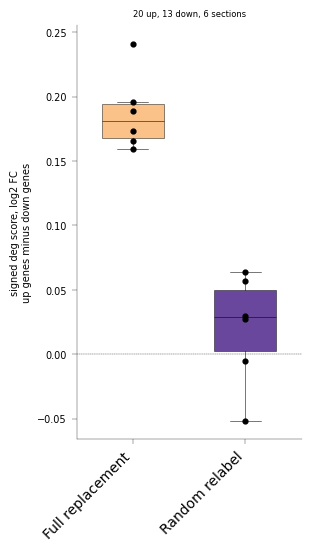

In [18]:
### Per-section signed deg score, full replacement against random relabel
signed_wide = signed.pivot_table(index='section', columns='arm', values='signed_score')[plot_modes]
positions = np.arange(len(plot_modes))

fig, ax = plt.subplots(figsize=(3, 5.4), constrained_layout=True)
bp = ax.boxplot([signed_wide[m].to_numpy() for m in plot_modes], positions=positions, widths=0.55,
                capwidths=0.275, patch_artist=True, showfliers=False,
                medianprops=dict(color=line_color, linewidth=line_lw * 1.5),
                whiskerprops=dict(color=line_color, linewidth=line_lw * 1.5),
                capprops=dict(color=line_color, linewidth=line_lw * 1.5),
                boxprops=dict(edgecolor=line_color, linewidth=line_lw * 1.5))
for patch, mode in zip(bp['boxes'], plot_modes):
    patch.set_facecolor(arm_color[mode])
    patch.set_alpha(0.85)
for section in signed_wide.index:
    ax.scatter(positions, signed_wide.loc[section, plot_modes].to_numpy(),
               color='black', s=12, zorder=2)
ax.axhline(0, color=line_color, linestyle='--', linewidth=line_lw)
ax.set_xticks(positions)
ax.set_xticklabels([mode_label[m] for m in plot_modes], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('signed deg score, log2 FC\nup genes minus down genes')
ax.set_title(f'{len(deg_used["up"])} up, {len(deg_used["down"])} down, {len(signed_wide)} sections',
             fontsize=6)
style_axes(ax)
fig.savefig(plot_path(f'tam_xmic_signed_score_{deg_tag}'), format='svg', dpi=600,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)


CV1-KID-0-FO-1 unperturbed 2760
CV1-KID-0-FO-1 full_replacement 2760
CV1-KID-0-FO-1 random_cells_uniform 2760
CV1-KID-0-FT-2 unperturbed 2789
CV1-KID-0-FT-2 full_replacement 2789
CV1-KID-0-FT-2 random_cells_uniform 2789
CV5-KID-0-FO-1 unperturbed 442
CV5-KID-0-FO-1 full_replacement 442
CV5-KID-0-FO-1 random_cells_uniform 442
CV6-KID-0-FT-1 unperturbed 1887
CV6-KID-0-FT-1 full_replacement 1887
CV6-KID-0-FT-1 random_cells_uniform 1887
CV7-KID-0-FT-2-s3 unperturbed 527
CV7-KID-0-FT-2-s3 full_replacement 527
CV7-KID-0-FT-2-s3 random_cells_uniform 527
CV9-KID-0-FT-2 unperturbed 1910
CV9-KID-0-FT-2 full_replacement 1910
CV9-KID-0-FT-2 random_cells_uniform 1910


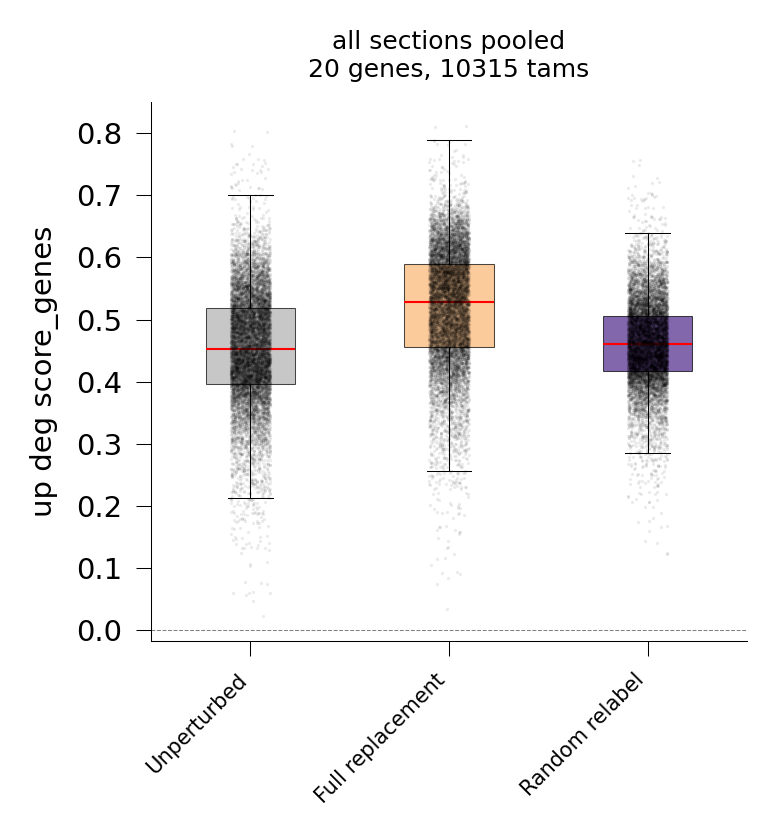

In [19]:
### Pooled up-deg score_genes over the mcc changed tams, three arms
def arm_chunk(x, section, group):
    return ad.AnnData(
        X=cp10k(x), var=pd.DataFrame(index=panel),
        obs=pd.DataFrame({'section': section, 'group': group},
                         index=[f'{group}-{section}-{i}' for i in range(x.shape[0])]))


group_order = ['unperturbed', 'full_replacement', 'random_cells_uniform']

parts = []
for section in sections:
    ctrl, pert, changed_ids = mcc_changed(section)
    for group in group_order:
        arm = {'unperturbed': ctrl, 'full_replacement': pert}.get(group)
        if arm is None:
            arm = sc.read_h5ad(gen_path(section, group))
        keep = pd.Index(arm.obs['cell_id'].astype(str)).isin(changed_ids) & tam_mask(arm)
        parts.append(arm_chunk(arm.obsm[key_xmic][keep], section, group))
        print(section, group, int(keep.sum()), flush=True)
        if arm is not ctrl and arm is not pert:
            del arm
        gc.collect()
    del ctrl, pert
    gc.collect()

combined = ad.concat(parts)
del parts
gc.collect()

sc.tl.score_genes(combined, gene_list=deg_used['up'], score_name='up_score',
                  ctrl_as_ref=True, ctrl_size=50, n_bins=25, random_state=0)
score_df = combined.obs.copy()
score_df.to_csv(f'{dir_save}/tam_deg_group_scoregenes_persection_3arm_{deg_tag}.csv', index=False)

vals = [score_df.loc[score_df['group'] == g, 'up_score'].to_numpy() for g in group_order]

fig, ax = plt.subplots(figsize=(2.6, 2.8), dpi=300)
bp = ax.boxplot(vals, positions=range(len(group_order)), widths=0.45, patch_artist=True,
                showfliers=False, medianprops=dict(color='red', linewidth=0.5),
                boxprops=dict(linewidth=line_lw), whiskerprops=dict(linewidth=line_lw),
                capprops=dict(linewidth=line_lw))
for patch, g in zip(bp['boxes'], group_order):
    patch.set_facecolor(arm_color[g])
    patch.set_alpha(0.7)
rng = np.random.default_rng(0)
for i, v in enumerate(vals):
    ax.scatter(i + rng.uniform(-0.1, 0.1, v.size), v, s=0.6, color='black', alpha=0.08,
               linewidths=0, zorder=3, rasterized=True)

ax.axhline(0, color='grey', linestyle='--', linewidth=line_lw)
ax.set_xticks(range(len(group_order)))
ax.set_xticklabels([mode_label[g] for g in group_order], rotation=45, ha='right', fontsize=5)
ax.set_ylabel('up deg score_genes')
ax.set_title(f'all sections pooled\n{len(deg_used["up"])} genes, {vals[0].size} tams', fontsize=6)
style_axes(ax)
fig.tight_layout()
fig.savefig(plot_path(f'tam_up_deg_group_scoregenes_pooled_allsections_3arm_{deg_tag}'),
            format='svg', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)


# Level4 TAM subtype DEGs

In [20]:
### Tam pseudobulk and deseq2 with depth as a covariate, split by level4 TAM state
min_tam_cells_state = 5
all_tam_label = 'All TAMs'
plot_labels = ['IFN+', 'SPP1+GRN+', 'IL1B+FCGR2A+']
score_labels = [all_tam_label] + plot_labels

pb_counts_state = {label: {} for label in plot_labels}
pb_meta_state = {label: [] for label in plot_labels}

for fn in sorted(f for f in os.listdir(root_sections) if f.endswith('.h5ad')):
    s = fn[:-len('.h5ad')]
    a = add_level4(sc.read_h5ad(f'{root_sections}/{fn}'))
    treatment = 'treated' if a.obs['drug'].astype(str).isin(icb_drugs).any() else 'untreated'
    tam = (a.obs['level_3_cell_type'] == ct_filter).to_numpy()
    level4 = a.obs['level_4_cell_type'].astype(str).to_numpy()
    tx = a.obs['transcript_counts'].to_numpy()

    for label in plot_labels:
        m = tam & (level4 == label)
        if m.sum() < min_tam_cells_state:
            continue
        pb_counts_state[label][s] = np.asarray(a.layers['counts'][m].sum(0)).ravel()
        pb_meta_state[label].append({'section': s, 'treatment': treatment,
                                     'n_tam': int(m.sum()),
                                     'median_tx': float(np.median(tx[m]))})
    del a
    gc.collect()

upreg_genes, downreg_genes = {all_tam_label: cov_up}, {all_tam_label: cov_down}
for label in plot_labels:
    counts_d = pd.DataFrame(pb_counts_state[label], index=genes).T.round().astype(int)
    meta_d = pd.DataFrame(pb_meta_state[label]).set_index('section').loc[counts_d.index]

    log_tx = np.log10(meta_d['median_tx'])
    meta_d['depth_z'] = (log_tx - log_tx.mean()) / log_tx.std()
    meta_d['treatment'] = pd.Categorical(meta_d['treatment'], categories=['untreated', 'treated'])

    counts_d = counts_d.loc[:, counts_d.columns.intersection(universe)]
    counts_d = counts_d.loc[:, (counts_d >= 10).sum(0) >= min(5, len(meta_d))]

    inference_d = DefaultInference(n_cpus=4)
    dds_d = DeseqDataSet(counts=counts_d, metadata=meta_d, design='~depth_z + treatment',
                         inference=inference_d, quiet=True)
    dds_d.deseq2()
    stat_d = DeseqStats(dds_d, contrast=['treatment', 'treated', 'untreated'],
                        inference=inference_d, quiet=True)
    stat_d.summary()
    stat_d.lfc_shrink(coeff='treatment[T.treated]')

    res_d = stat_d.results_df.sort_values('padj')
    tag = label.replace('+', 'plus').replace('/', '-').replace(' ', '_')
    res_d.to_csv(f'{dir_save}/tam_deseq2_{tag}_depthcov.csv')

    sig_d = res_d[(res_d['padj'] < deg_p_max) & (res_d['log2FoldChange'].abs() > deg_min_abs_lfc)]
    upreg_genes[label] = sig_d.index[sig_d['log2FoldChange'] > 0].astype(str).tolist()
    downreg_genes[label] = sig_d.index[sig_d['log2FoldChange'] < 0].astype(str).tolist()
    print(f'{label}: {len(meta_d)} sections, '
          f'{int(meta_d["treatment"].eq("treated").sum())} treated, '
          f'{len(upreg_genes[label])} up, {len(downreg_genes[label])} down', flush=True)

pd.concat(
    [pd.DataFrame({'level_4_cell_type': label, 'gene': gl, 'direction': direction})
     for genes_dict, direction in [(upreg_genes, 'up'), (downreg_genes, 'down')]
     for label, gl in genes_dict.items()],
    ignore_index=True,
).to_csv(f'{dir_save}/tam_deseq2_depthcov_degs_per_subtype.csv', index=False)


/nfs/team361/zh4/Environments/mintflow_perturbation_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/zh4/Environments/mintflow_perturbation_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/zh4/Environments/mintflow_perturbation_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/zh4/Environments/mintflow_perturbation_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


IFN+: 48 sections, 8 treated, 8 up, 8 down


/nfs/team361/zh4/Environments/mintflow_perturbation_2/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)


SPP1+GRN+: 49 sections, 9 treated, 10 up, 7 down


/nfs/team361/zh4/Environments/mintflow_perturbation_2/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)


IL1B+FCGR2A+: 49 sections, 9 treated, 13 up, 11 down


In [21]:
### Per-cell up-deg log2 FC per level4 state, every arm against the unperturbed baseline
deg_tag_mcc = f'{deg_tag}_mccchanged_percell'
gp_union, gp_idx = gp_columns({label: upreg_genes[label] for label in score_labels})

rows = []
for section in sections:
    ctrl, ref, changed_ids = mcc_changed(section)
    cid_ctrl = pd.Index(ctrl.obs['cell_id'].astype(str))
    keep = cid_ctrl.isin(changed_ids) & tam_mask(ctrl)
    cid_keep = cid_ctrl[keep]
    x_ctrl = np.clip(ctrl.obsm[key_xmic][np.ix_(keep, gp_union)], 0, None)
    level4 = ctrl.obs['level_4_cell_type'].astype(str).to_numpy()[keep]
    masks = {l: np.ones(len(cid_keep), bool) if l == all_tam_label else (level4 == l)
             for l in score_labels}

    for label in score_labels:
        rows.append({'section': section, 'mode': 'unperturbed', 'level_4_cell_type': label,
                     'log2FC': 0.0, 'n_cells': int(masks[label].sum())})

    for mode in modes:
        a = ref if mode == mcc_reference_mode else sc.read_h5ad(gen_path(section, mode))
        # the fold change is per cell, so the arms are matched on cell id rather than row order
        pos = pd.Index(a.obs['cell_id'].astype(str)).get_indexer(cid_keep)
        take = pos >= 0
        x_pert = np.clip(a.obsm[key_xmic][np.ix_(pos[take], gp_union)], 0, None)
        x_base = x_ctrl[take]

        for label in score_labels:
            m = masks[label][take]
            if not m.any() or label not in gp_idx:
                continue
            cols = gp_idx[label]
            lfc = np.log2((x_pert[m][:, cols].mean(1) + pseudo)
                          / (x_base[m][:, cols].mean(1) + pseudo))
            rows.append({'section': section, 'mode': mode, 'level_4_cell_type': label,
                         'log2FC': float(lfc.mean()), 'n_cells': int(m.sum())})

        if a is not ref:
            del a
        del x_pert, x_base
        gc.collect()

    print(f'scored {section}, {int(keep.sum())} mcc changed tams', flush=True)
    del ctrl, ref, cid_ctrl, x_ctrl
    gc.collect()

subtype_df = pd.DataFrame(rows)
subtype_df.to_csv(f'{dir_save}/tam_subtype_deg_score_raw_{deg_tag_mcc}.csv', index=False)

print(subtype_df.pivot_table(index='level_4_cell_type', columns='mode', values='n_cells',
                             aggfunc='sum').to_string())


scored CV1-KID-0-FO-1, 2760 mcc changed tams
scored CV1-KID-0-FT-2, 2789 mcc changed tams
scored CV5-KID-0-FO-1, 442 mcc changed tams
scored CV6-KID-0-FT-1, 1887 mcc changed tams
scored CV7-KID-0-FT-2-s3, 527 mcc changed tams
scored CV9-KID-0-FT-2, 1910 mcc changed tams
mode               dose_response_25pct  dose_response_50pct  dose_response_75pct  full_replacement  random_cells_uniform  unperturbed
level_4_cell_type                                                                                                                    
All TAMs                         10315                10315                10315             10315                 10315        10315
IFN+                              1479                 1479                 1479              1479                  1479         1479
IL1B+FCGR2A+                      2970                 2970                 2970              2970                  2970         2970
SPP1+GRN+                         1438                 1438

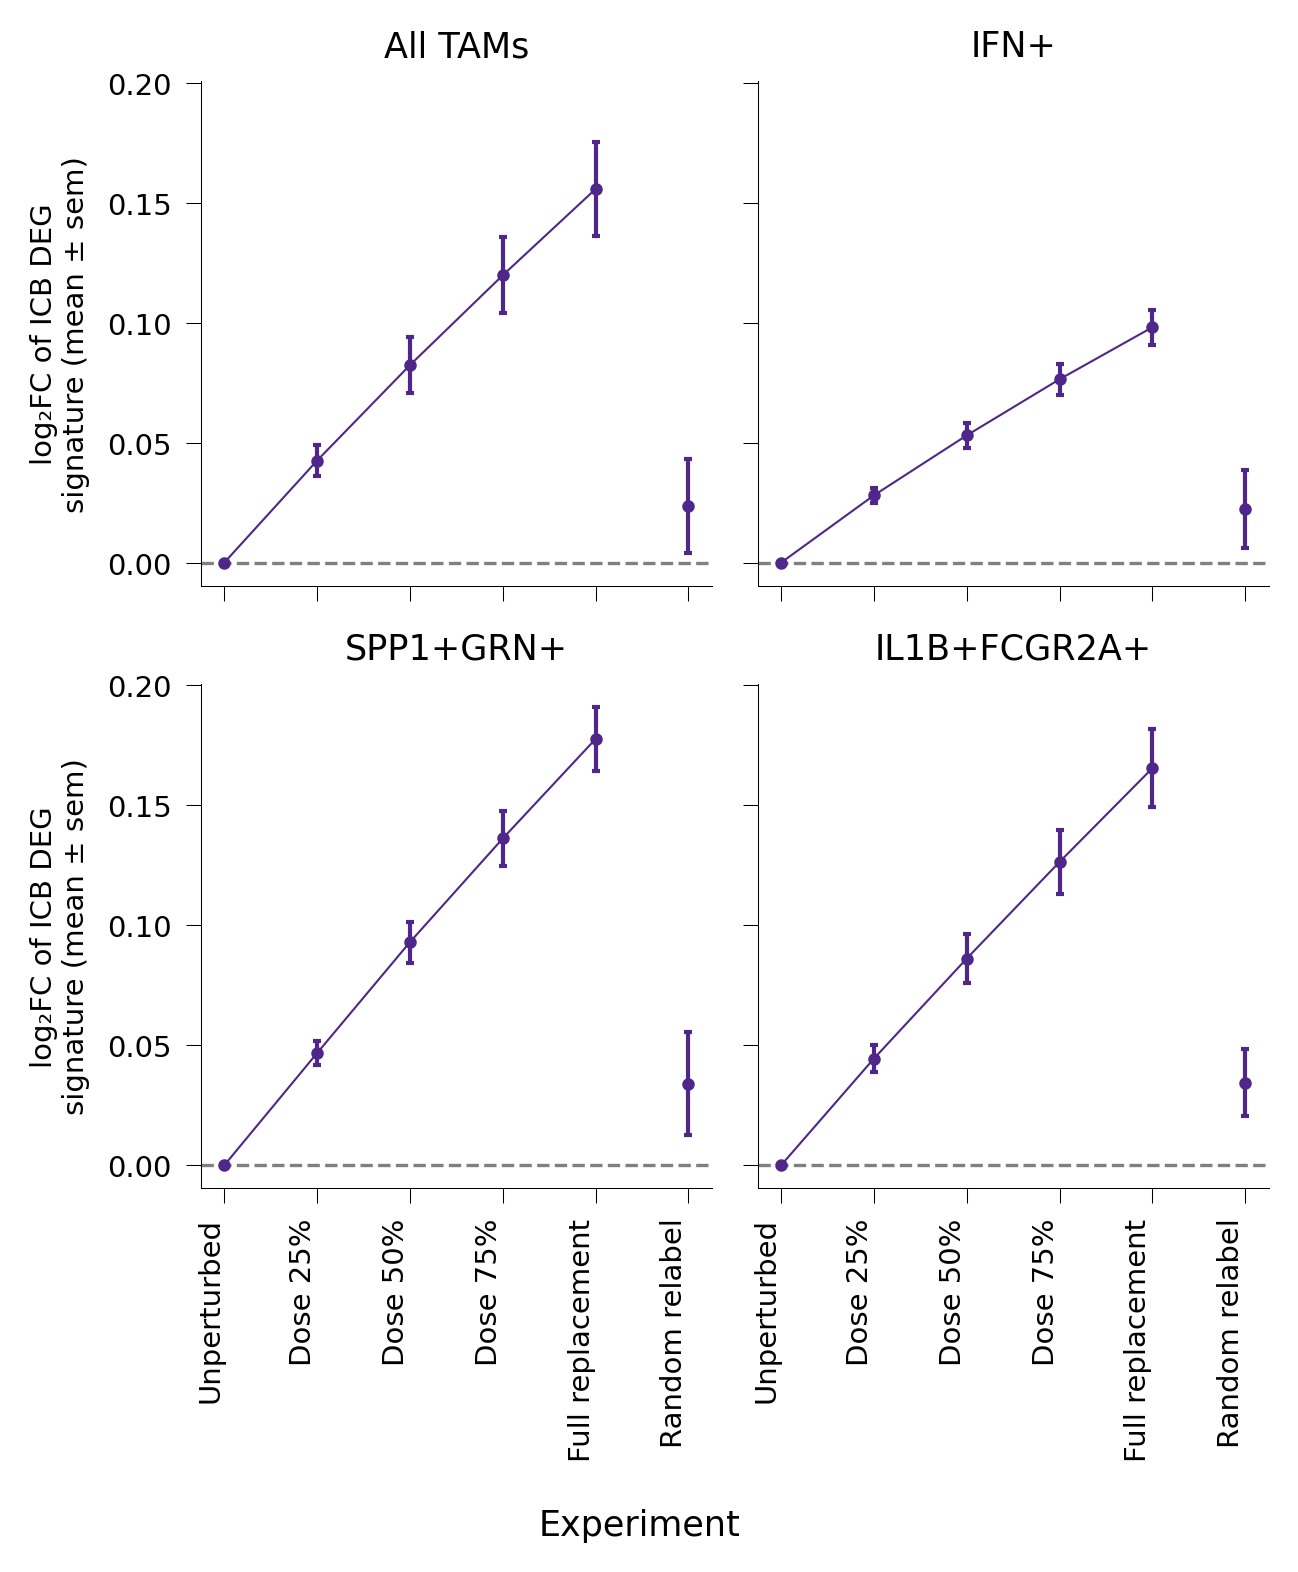

In [22]:
### Mean +- sem log2 FC scatter, 2x2 panel
exp_order_state = ['unperturbed', 'dose_response_25pct', 'dose_response_50pct',
                   'dose_response_75pct', 'full_replacement', 'random_cells_uniform']
detached = ['random_cells_uniform']  # random relabel stays off the connected dose curve

stats = (subtype_df.groupby(['level_4_cell_type', 'mode'])['log2FC']
         .agg(['mean', 'sem']).fillna(0.0))
xpos = {e: i for i, e in enumerate(exp_order_state)}

fig, axes = plt.subplots(2, 2, figsize=(4.4, 5.2), dpi=300, sharex=True, sharey=True)
for idx, (ax, label) in enumerate(zip(axes.ravel(), score_labels)):
    s = stats.loc[label]
    for seg in ([e for e in exp_order_state if e not in detached], detached):
        seg = [e for e in seg if e in s.index]
        if not seg:
            continue
        ax.errorbar([xpos[e] for e in seg], s.loc[seg, 'mean'], yerr=s.loc[seg, 'sem'],
                    color='#4f278b', marker='o', linewidth=0.5, elinewidth=1.0,
                    capsize=1, markersize=2)
    ax.set_title(label)
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8, zorder=0)
    ax.set_xticks(range(len(exp_order_state)))
    ax.set_xticklabels([mode_label[e] for e in exp_order_state], rotation=90, ha='right')
    if idx % 2 == 0:
        ax.set_ylabel('log₂FC of ICB DEG\nsignature (mean ± sem)')
    style_axes(ax)

fig.supxlabel('Experiment')
fig.tight_layout()
fig.savefig(plot_path(f'tam_deg_signature_dose_response_{deg_tag_mcc}'), format='svg', dpi=600,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)


# Dotplots

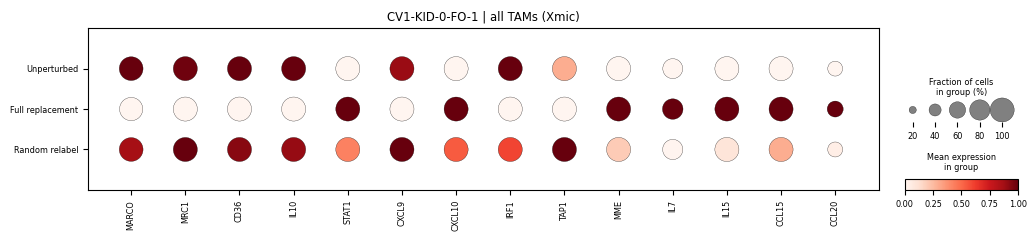

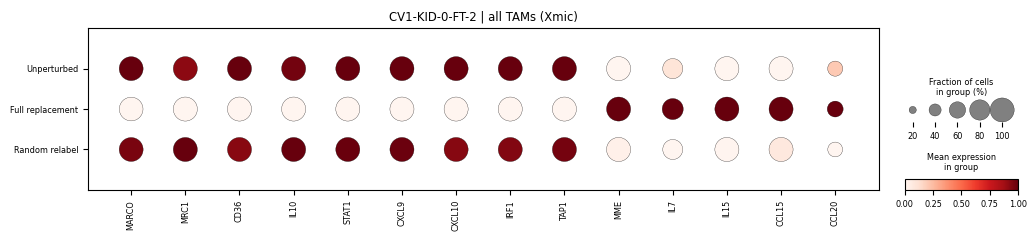

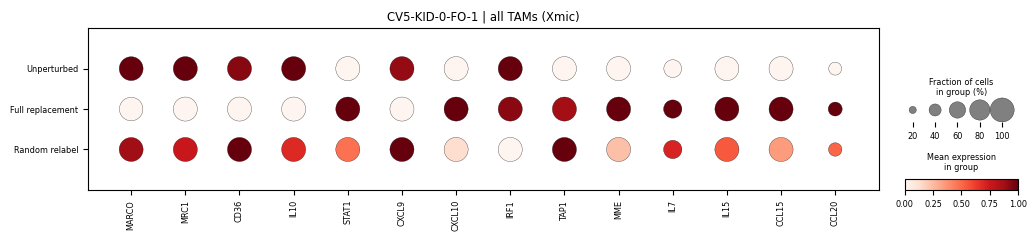

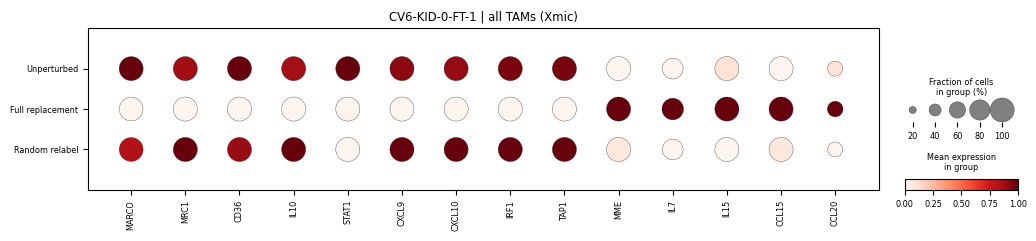

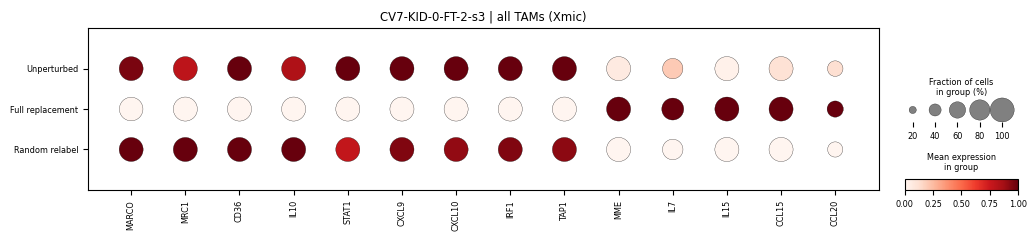

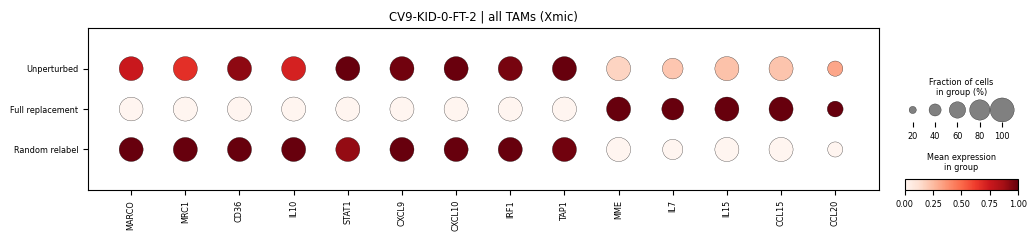

In [23]:
### All-tam signature dotplot on Xmic, unperturbed against full replacement and random relabel
# same signature genes as the IFN+ TAM dotplot in ccRCC_Fig4_prior_analysis.ipynb, but scored
# across all TAMs (no level_4 subtype filter) and on Xmic only (not Xint + Xmic)
dotplot_genes = [
    'MARCO', 'MRC1', 'CD36', 'IL10', 'STAT1', 'CXCL9', 'CXCL10', 'IRF1', 'TAP1', 'MME', 'IL7', 'IL15', 'CCL15', 'CCL20']
available = [g for g in dotplot_genes if g in panel]
exp_order_dotplot = ['unperturbed', 'full_replacement', 'random_cells_uniform']

for section in sections:
    parts = []
    for mode in exp_order_dotplot:
        a = sc.read_h5ad(gen_path(section, mode))
        keep = tam_mask(a)
        if keep.sum() == 0:
            del a
            gc.collect()
            continue
        cols = a.var_names.get_indexer(available)
        x = np.clip(np.asarray(a.obsm[key_xmic], dtype=np.float64)[keep][:, cols], 0, None)
        parts.append(ad.AnnData(
            X=x, var=pd.DataFrame(index=available),
            obs=pd.DataFrame({'experiment': mode_label[mode]},
                             index=[f'{mode}__{i}' for i in range(x.shape[0])]),
        ))
        del a
        gc.collect()

    if not parts:
        continue
    labels_order = [mode_label[m] for m in exp_order_dotplot
                    if mode_label[m] in {p.obs['experiment'].iat[0] for p in parts}]
    sec = ad.concat(parts, join='outer', merge='same')
    sec.obs['experiment'] = pd.Categorical(
        sec.obs['experiment'].astype(str), categories=labels_order, ordered=True
    )
    sc.pp.log1p(sec)

    dp = sc.pl.dotplot(
        sec, var_names=available, groupby='experiment',
        categories_order=labels_order, use_raw=False, expression_cutoff=0.0,
        figsize=(max(len(available) * 0.6, 12), 0.7 * len(labels_order)),
        title=f'{section} | all TAMs (Xmic)', standard_scale='var',
        smallest_dot=0, return_fig=True,
    )
    dp.largest_dot = 300
    dp.savefig(plot_path(f'dotplot_allTAM_Xmic_{section.replace("/", "_")}'),
               dpi=600, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close('all')
